<a href="https://www.kaggle.com/code/aliaslam25/ai-productivity-prediction-stack-overflow-2025?scriptVersionId=304851363" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Phase 2 — Visualization & Preprocessing

**Project:** ML project using the 2025 Stack Overflow Developer Survey.  
**Goal:** Predict whether a professional developer agrees that *"AI agents have increased their productivity"* (binary classification).  
**Dataset:** `survey_results_public.csv` — raw survey data.  
**This notebook:** Loads raw data, constructs the binary target from the AIAgentImpact Likert matrix, filters to professional developers, performs statistical and visual analysis, engineers features, runs a missingness audit, preprocesses (imputation, one-hot encoding), fits baseline models, and saves the model-ready data to `phase2_preprocessed.csv` for Phase 3.

## Section 1 — Data Loading

Load the raw survey CSV and confirm shape and first rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/aliaslam25/stack-overflow-developer-survey-2025/survey_results_public.csv", low_memory=False)
print("Shape:", df.shape)
print(df.head())

Shape: (49191, 172)
   ResponseId                      MainBranch              Age  \
0           1  I am a developer by profession  25-34 years old   
1           2  I am a developer by profession  25-34 years old   
2           3  I am a developer by profession  35-44 years old   
3           4  I am a developer by profession  35-44 years old   
4           5  I am a developer by profession  35-44 years old   

                                           EdLevel  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1              Associate degree (A.A., A.S., etc.)   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
4  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   

                                          Employment  \
0                                           Employed   
1                                           Employed   
2  Independent contractor, freelancer, or self-em...   
3                                 

## Section 2 — Target Construction

Build a binary target from the AIAgentImpact Likert matrix: search for the statement *"AI agents have increased my productivity"* in agree vs disagree columns. Rows where the statement does not appear in any of those columns are dropped.

In [2]:
PRODUCTIVITY_STR = "AI agents have increased my productivity"
agree_cols = ["AIAgentImpactStrongly agree", "AIAgentImpactSomewhat agree"]
disagree_cols = ["AIAgentImpactNeutral", "AIAgentImpactSomewhat disagree", "AIAgentImpactStrongly disagree"]

def get_target(row):
    for c in agree_cols:
        if pd.notna(row[c]) and PRODUCTIVITY_STR in str(row[c]):
            return 1
    for c in disagree_cols:
        if pd.notna(row[c]) and PRODUCTIVITY_STR in str(row[c]):
            return 0
    return np.nan

df["target"] = df.apply(get_target, axis=1)
df = df[df["target"].notna()].copy()
print("Target value_counts:")
print(df["target"].value_counts().to_string())

Target value_counts:
target
1.0    8776
0.0    3995


**Why this target?** The AIAgentImpact matrix contains one statement that directly measures perceived productivity from AI agents: *"AI agents have increased my productivity."* It is the most direct available proxy for AI productivity belief in the dataset. Agree (Strongly/Somewhat) = 1, Disagree/Neutral = 0.

## Section 3 — Cohort Filter

Restrict to professional developers: MainBranch = *"I am a developer by profession"*, Employment in [Employed, Independent contractor/freelancer], WorkExp not null and not 0.

In [3]:
shape_before = df.shape[0]
employment_ok = df["Employment"].isin(["Employed", "Independent contractor, freelancer, or self-employed"])
df = df[
    (df["MainBranch"] == "I am a developer by profession")
    & employment_ok
    & df["WorkExp"].notna()
    & (df["WorkExp"] != 0)
].copy()
shape_after = df.shape[0]
print(f"Shape before cohort filter: ({shape_before}, {df.shape[1]})")
print(f"Shape after cohort filter:  ({shape_after}, {df.shape[1]})")

Shape before cohort filter: (12771, 173)
Shape after cohort filter:  (9513, 173)


**Rationale:** Hobbyists, students, and the unemployed have different relationships with productivity tooling; mixing them would confound a model targeting professional productivity. WorkExp not null and ≠ 0 ensures we keep only practicing developers with at least some experience.

## Column selection (for Section 4)

Restrict to a whitelist of columns with direct theoretical link to AI productivity. This gives the "pre-engineered" dataframe for statistical analysis.

In [4]:
WHITELIST = [
    "AISelect", "AISent", "AIAcc", "AIComplex", "AIFrustration", "AIAgents", "AIAgentChange",
    "AIAgent_Uses", "AgentUsesGeneral", "AIHuman",
    "AIToolCurrently mostly AI", "AIToolCurrently partially AI", "AIToolPlan to mostly use AI",
    "AIToolPlan to partially use AI", "AIToolDon't plan to use AI for this task",
    "AIModelsHaveWorkedWith", "DevEnvsHaveWorkedWith",
    "DevType", "WorkExp", "YearsCode", "OrgSize", "ICorPM", "RemoteWork", "Age", "EdLevel", "Industry",
]
cols = [c for c in WHITELIST if c in df.columns]
missing = set(WHITELIST) - set(cols)
if missing:
    print("Missing from data:", missing)
df = df[["target"] + cols].copy()
print("Shape after column selection:", df.shape)

Shape after column selection: (9513, 27)


## Section 4 — Statistical Analysis (Phase 2 requirement 1a)

Describe the pre-engineered dataframe, missing value counts per column, and dtypes.

In [5]:
print("--- describe() ---")
print(df.describe(include="all"))

print("\n--- Missing value counts per column ---")
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
if len(missing_counts) > 0:
    for col in missing_counts.index:
        pct = 100 * missing_counts[col] / len(df)
        print(f"{col}: {missing_counts[col]} ({pct:.2f}%)")
else:
    print("No missing values in selected columns.")

print("\n--- dtypes summary ---")
print(df.dtypes)

--- describe() ---
             target                   AISelect     AISent           AIAcc  \
count   9513.000000                       9506       9505            9487   
unique          NaN                          5          6               5   
top             NaN  Yes, I use AI tools daily  Favorable  Somewhat trust   
freq            NaN                       6596       4202            3597   
mean       0.684852                        NaN        NaN             NaN   
std        0.464599                        NaN        NaN             NaN   
min        0.000000                        NaN        NaN             NaN   
25%        0.000000                        NaN        NaN             NaN   
50%        1.000000                        NaN        NaN             NaN   
75%        1.000000                        NaN        NaN             NaN   
max        1.000000                        NaN        NaN             NaN   

                                            AIComplex  \

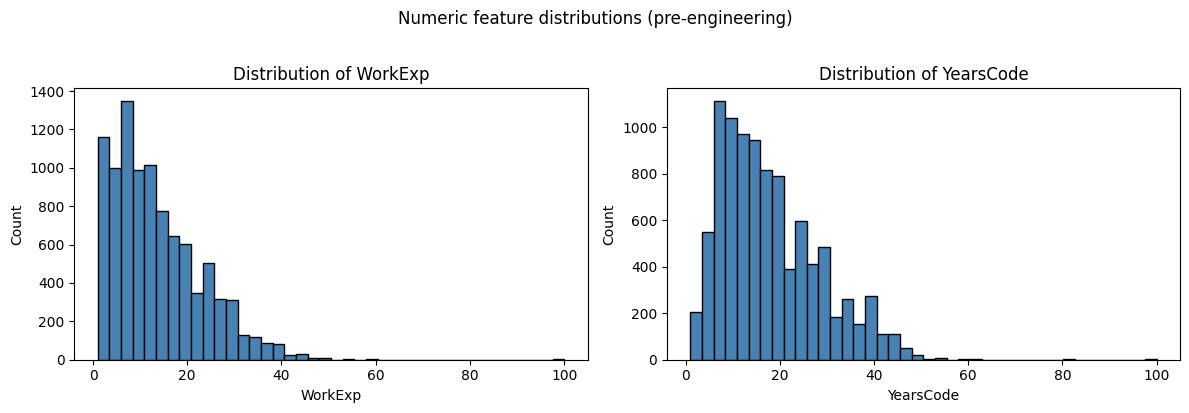

In [6]:
# Distribution plots for numeric features (statistical analysis visualization)
numeric_cols_to_plot = ["WorkExp", "YearsCode"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(numeric_cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Distribution of {col}")
plt.suptitle("Numeric feature distributions (pre-engineering)", y=1.02)
plt.tight_layout()
plt.show()

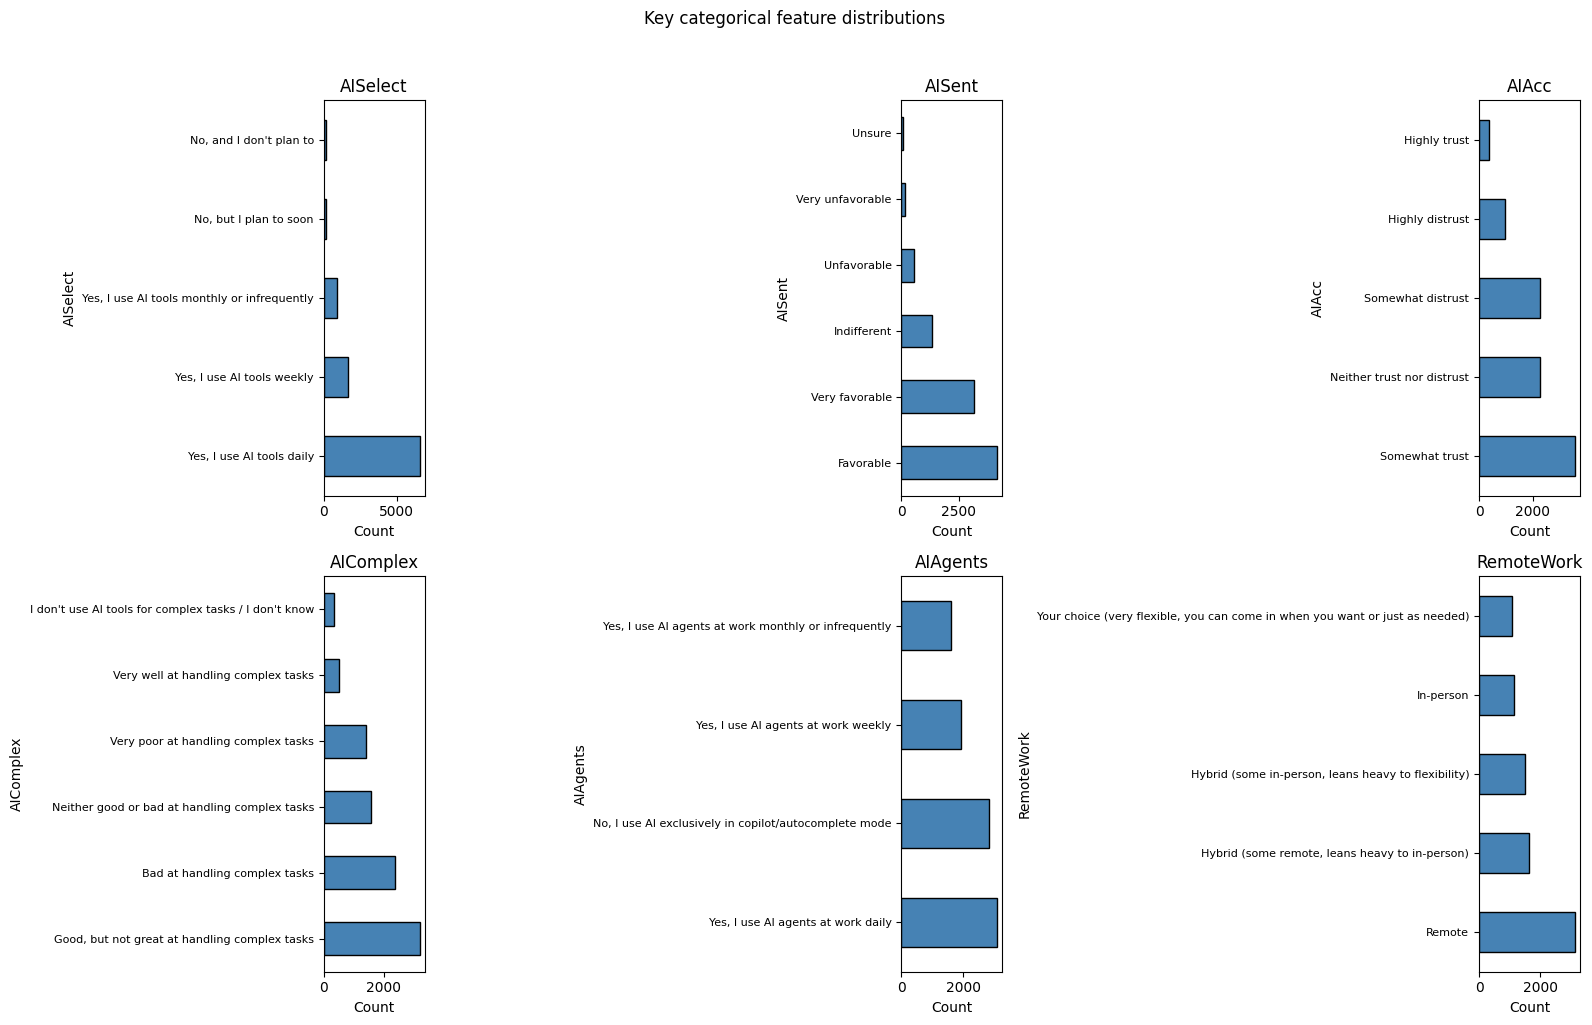

In [7]:
# Value counts bar charts for key categorical columns
cat_cols = ["AISelect", "AISent", "AIAcc", "AIComplex", "AIAgents", "RemoteWork"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(cat_cols):
    ax = axes.flat[i]
    vc = df[col].value_counts().head(6)
    vc.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("Count")
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle("Key categorical feature distributions", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** WorkExp and YearsCode are right-skewed; most respondents have under 15 years of experience. Categorical features show clear modal responses (e.g., majority use AI tools daily; most have a favorable AI sentiment).

**Notes:** After feature engineering we will see that `edlevel_ord` has very high missingness (~76–77%) because many respondents skip the education question. `OrgSize` and other categoricals also have non-trivial missingness. Numeric columns like WorkExp and YearsCode may have a few percent missing.

## Section 5 — Feature Engineering

Apply ordinal mappings, count features, binary flags, DevType bucketing, and Industry rare-category collapse. Use the `norm()` helper for UTF-8 replacement characters. Keep only the 29-column whitelist at the end.

In [8]:
# --- Ordinal mappings (exact strings)
AISELECT_MAP = {
    "Yes, I use AI tools daily": 4, "Yes, I use AI tools weekly": 3,
    "Yes, I use AI tools monthly or infrequently": 2, "No, but I plan to soon": 1, "No, and I don't plan to": 0,
}
AISENT_MAP = {"Very favorable": 4, "Favorable": 3, "Indifferent": 2, "Unfavorable": 1, "Very unfavorable": 0}
AIACC_MAP = {"Highly trust": 4, "Somewhat trust": 3, "Neither trust nor distrust": 2, "Somewhat distrust": 1, "Highly distrust": 0}
AICOMPLEX_MAP = {
    "Very well at handling complex tasks": 4, "Good, but not great at handling complex tasks": 3,
    "Neither good or bad at handling complex tasks": 2, "Bad at handling complex tasks": 1, "Very poor at handling complex tasks": 0,
    "I don't use AI tools for complex tasks / I don't know": 2,
}
AIAGENTS_MAP = {
    "Yes, I use AI agents at work daily": 4, "Yes, I use AI agents at work weekly": 3,
    "Yes, I use AI agents at work monthly or infrequently": 2,
    "No, I use AI exclusively in copilot/autocomplete mode": 1, "No, but I plan to": 1, "No, and I don't plan to": 0,
}
AGENT_CHANGE_MAP = {
    "Yes, to a great extent": 2, "Yes, somewhat": 1,
    "Not at all or minimally": 0,
    "No, but my development work has changed somewhat due to non-AI factors": 0,
    "No, but my development work has significantly changed due to non-AI factors": 0,
}
ORGSIZE_MAP = {
    "Just me - I am a freelancer, sole proprietor, etc.": 0, "Less than 20 employees": 1, "20 to 99 employees": 2,
    "100 to 499 employees": 3, "500 to 999 employees": 4, "1,000 to 4,999 employees": 5,
    "5,000 to 9,999 employees": 6, "10,000 or more employees": 7, "I don't know": np.nan,
}
AGE_MAP = {
    "Under 18 years old": 0, "18-24 years old": 1, "25-34 years old": 2, "35-44 years old": 3,
    "45-54 years old": 4, "55-64 years old": 5, "65 years or older": 6, "Prefer not to say": np.nan,
}
EDLEVEL_MAP = {
    "Primary/elementary school": 0, "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2, "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4, "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6, "Other (please specify):": np.nan,
}

def count_semi(s):
    if pd.isna(s) or str(s).strip() == "":
        return 0
    return len([x for x in str(s).split(";") if x.strip()])

def norm(s):
    return str(s).replace("\ufffd", "'") if pd.notna(s) else s

df["aiselect_ord"] = df["AISelect"].map(AISELECT_MAP)
df["aisent_ord"] = df["AISent"].map(AISENT_MAP)
df["AIAcc_ord"] = df["AIAcc"].map(AIACC_MAP)
df["AIComplex_ord"] = df["AIComplex"].map(AICOMPLEX_MAP)
df["aifrust_count"] = df["AIFrustration"].apply(count_semi)
df["aiagents_ord"] = df["AIAgents"].map(AIAGENTS_MAP)
df["agent_change_ord"] = df["AIAgentChange"].map(AGENT_CHANGE_MAP)

uses = df["AIAgent_Uses"].fillna("").astype(str) + ";" + df["AgentUsesGeneral"].fillna("").astype(str)
df["agent_use_breadth"] = uses.apply(lambda s: count_semi(s) if s.strip() != ";" else 0)

df["ai_tasks_now"] = (df["AIToolCurrently mostly AI"].apply(count_semi) + df["AIToolCurrently partially AI"].apply(count_semi))
df["ai_tasks_planned"] = (df["AIToolPlan to mostly use AI"].apply(count_semi) + df["AIToolPlan to partially use AI"].apply(count_semi))
df["ai_tasks_avoided"] = df["AIToolDon't plan to use AI for this task"].apply(count_semi)
df["aihuman_count"] = df["AIHuman"].apply(count_semi)
df["llm_count"] = df["AIModelsHaveWorkedWith"].apply(count_semi)

def has_sub(s, sub):
    return 1 if pd.notna(s) and sub.lower() in str(s).lower() else 0
df["uses_openai"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "openai") or has_sub(s, "gpt"))
df["uses_claude"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "claude"))
df["uses_gemini"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "gemini"))
df["uses_llama"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "llama"))
df["uses_deepseek"] = df["AIModelsHaveWorkedWith"].apply(lambda s: has_sub(s, "deepseek"))
for col in ["uses_openai", "uses_claude", "uses_gemini", "uses_llama", "uses_deepseek"]:
    df[col] = df[col].astype(int)

AI_EDITORS = ["Cursor", "Copilot", "Claude Code", "Cline", "Windsurf", "Bolt", "Lovable"]
def has_ai_editor(s):
    if pd.isna(s): return 0
    s = str(s).lower()
    return 1 if any(e.lower() in s for e in AI_EDITORS) else 0
df["has_ai_editor"] = df["DevEnvsHaveWorkedWith"].apply(has_ai_editor)

BUCKET_ORDER = [
    ("Data/AI", ["Data scientist", "Data engineer", "AI/ML engineer", "Applied scientist", "Data or business analyst"]),
    ("Infrastructure/Ops", ["Cloud infrastructure", "DevOps", "System administrator", "Cybersecurity", "InfoSec"]),
    ("Web/Software", ["Developer, front-end", "Developer, back-end", "Developer, full-stack", "Developer, desktop", "Developer, mobile", "Developer, QA", "Developer, game", "Developer, AI apps", "Architect, software"]),
]
def devtype_bucket(s):
    if pd.isna(s) or str(s).strip() == "": return "Other/Niche"
    first = str(s).split(";")[0].strip()
    for bucket, keywords in BUCKET_ORDER:
        if any(kw in first for kw in keywords): return bucket
    return "Other/Niche"
df["DevTypeBucket"] = df["DevType"].apply(devtype_bucket)

df["orgsize_ord"] = df["OrgSize"].apply(norm).map(ORGSIZE_MAP)
df["is_manager"] = (df["ICorPM"] == "People manager").astype(int)
df["age_ord"] = df["Age"].apply(norm).map(AGE_MAP)
df["edlevel_ord"] = df["EdLevel"].apply(norm).map(EDLEVEL_MAP)

industry_counts = df["Industry"].dropna().value_counts()
n_valid = industry_counts.sum()
threshold = max(1, int(0.03 * n_valid))
rare = industry_counts[industry_counts < threshold].index.tolist()
df["Industry"] = df["Industry"].where(~df["Industry"].isin(rare), "Other")
df["Industry"] = df["Industry"].replace("Other:", "Other")

keep = ["target", "aiselect_ord", "aisent_ord", "AIAcc_ord", "AIComplex_ord", "aifrust_count", "aiagents_ord", "agent_change_ord",
        "agent_use_breadth", "ai_tasks_now", "ai_tasks_planned", "ai_tasks_avoided", "aihuman_count", "llm_count",
        "uses_openai", "uses_claude", "uses_gemini", "uses_llama", "uses_deepseek", "has_ai_editor", "DevTypeBucket",
        "WorkExp", "YearsCode", "orgsize_ord", "is_manager", "RemoteWork", "age_ord", "edlevel_ord", "Industry"]
df = df[keep].copy()
print(df.shape)

(9513, 29)


**What was done:** (1) **Ordinals** — AISelect, AISent, AIAcc, AIComplex, AIAgents, AIAgentChange, OrgSize, Age, EdLevel mapped to integers 0–4 (or 0–7 for OrgSize) using exact survey strings; `norm()` fixes UTF-8 replacement chars. (2) **Count features** — aifrust_count, agent_use_breadth, ai_tasks_now/planned/avoided, aihuman_count, llm_count from semicolon-separated lists. (3) **Binary flags** — uses_openai/claude/gemini/llama/deepseek, has_ai_editor from substring match. (4) **DevTypeBucket** — first role from DevType collapsed into Data/AI, Infrastructure/Ops, Web/Software, Other/Niche. (5) **Industry** — categories &lt; 3% collapsed to "Other". (6) **Keep** — 29-column whitelist for modeling.

## Section 6 — Visual Analysis (Phase 2 requirement 1b)

Produce target balance, mean ordinals by target, count features by target, correlation heatmap, missingness bar chart, and two additional plots.

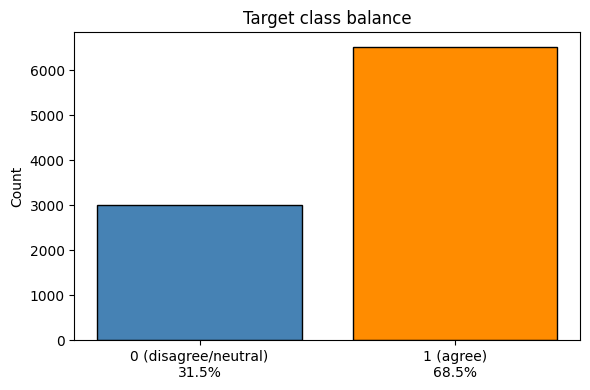

In [9]:
# Plot 1 — Target class balance
vc = df["target"].value_counts().sort_index()
pcts = (vc / len(df) * 100).round(1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([0, 1], vc.values, color=["steelblue", "darkorange"], edgecolor="black")
ax.set_xticks([0, 1])
ax.set_xticklabels([f"0 (disagree/neutral)\n{pcts.get(0, 0)}%", f"1 (agree)\n{pcts.get(1, 0)}%"])
ax.set_ylabel("Count")
ax.set_title("Target class balance")
plt.tight_layout()
plt.show()

**Observation:** The target is moderately imbalanced (e.g. ~68.5% agree vs ~31.5% disagree/neutral). Not severe enough to require oversampling; we use `class_weight="balanced"` in baseline models.

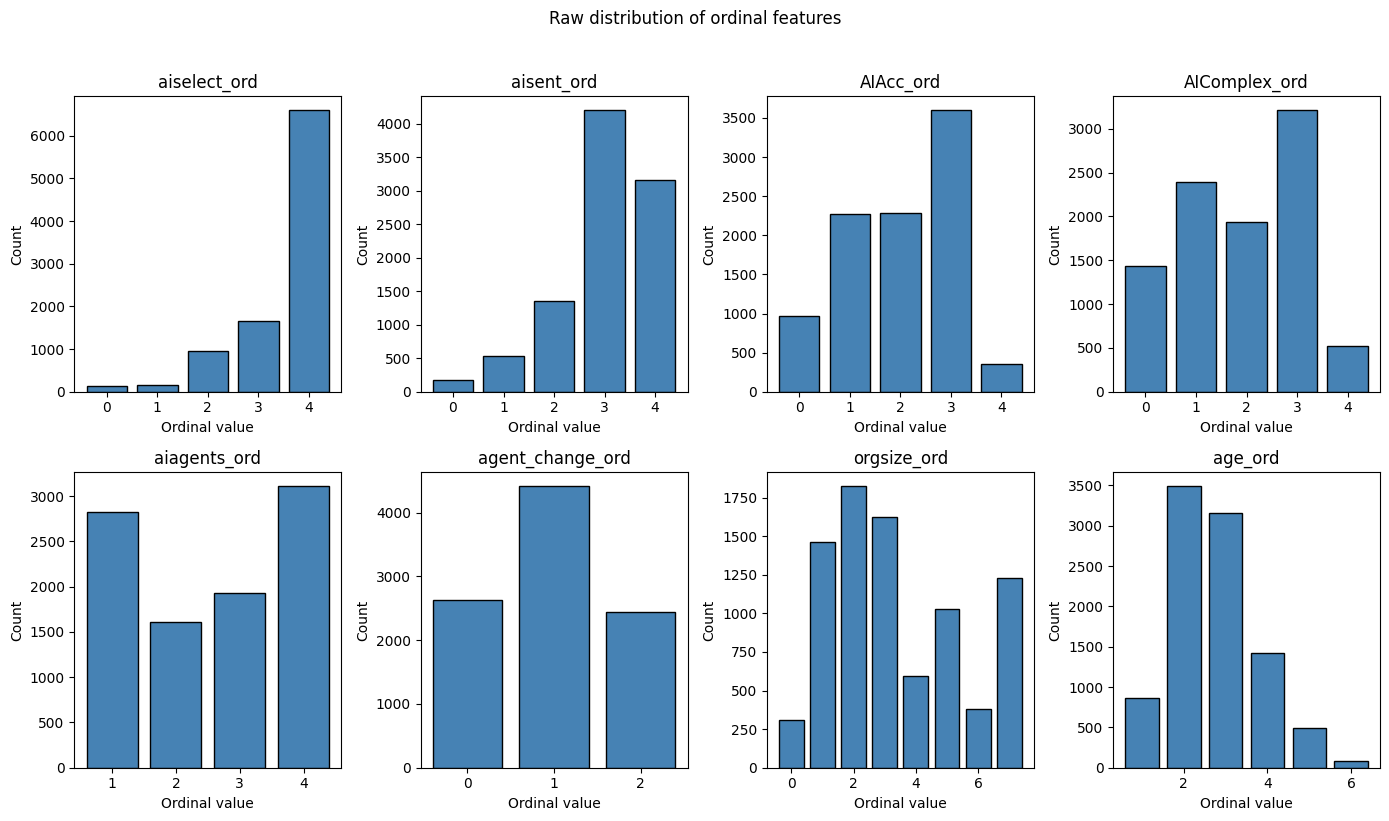

In [10]:
# Ordinal feature raw distributions (count plots)
ord_cols_plot = ["aiselect_ord", "aisent_ord", "AIAcc_ord", "AIComplex_ord",
                 "aiagents_ord", "agent_change_ord", "orgsize_ord", "age_ord"]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for i, col in enumerate(ord_cols_plot):
    ax = axes.flat[i]
    vc = df[col].dropna().value_counts().sort_index()
    ax.bar(vc.index, vc.values, color="steelblue", edgecolor="black")
    ax.set_xlabel("Ordinal value")
    ax.set_ylabel("Count")
    ax.set_title(col)
plt.suptitle("Raw distribution of ordinal features", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** `aiselect_ord` is heavily skewed toward value 4 (daily AI use), confirming the cohort is composed of active AI users. `aisent_ord` skews toward favorable (3–4). `aiagents_ord` has more spread, showing varied agent adoption levels. `age_ord` peaks at 2 (25–34 years old).

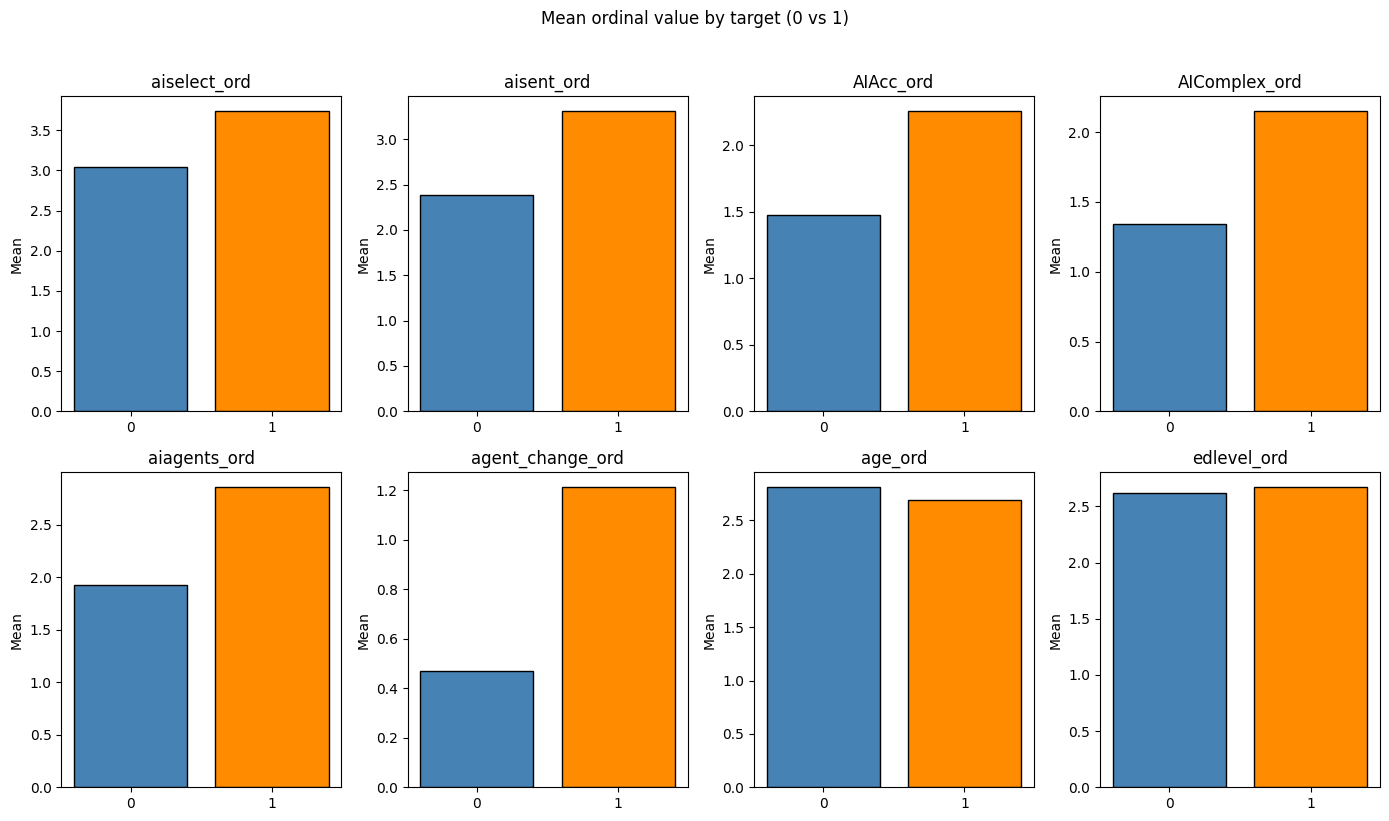

In [11]:
# Plot 2 — Mean ordinal value by target (2×4 subplot)
ord_cols = ["aiselect_ord", "aisent_ord", "AIAcc_ord", "AIComplex_ord", "aiagents_ord", "agent_change_ord", "age_ord", "edlevel_ord"]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for i, col in enumerate(ord_cols):
    ax = axes.flat[i]
    means = df.groupby("target")[col].mean()
    ax.bar([0, 1], [means.get(0, 0), means.get(1, 0)], color=["steelblue", "darkorange"], edgecolor="black")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_ylabel("Mean")
    ax.set_title(col)
plt.suptitle("Mean ordinal value by target (0 vs 1)", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** Respondents who agree (target=1) tend to have higher means on aiselect_ord, aisent_ord, AIAcc_ord, AIComplex_ord, aiagents_ord, agent_change_ord. age_ord and edlevel_ord show weaker separation, as expected for demographics.

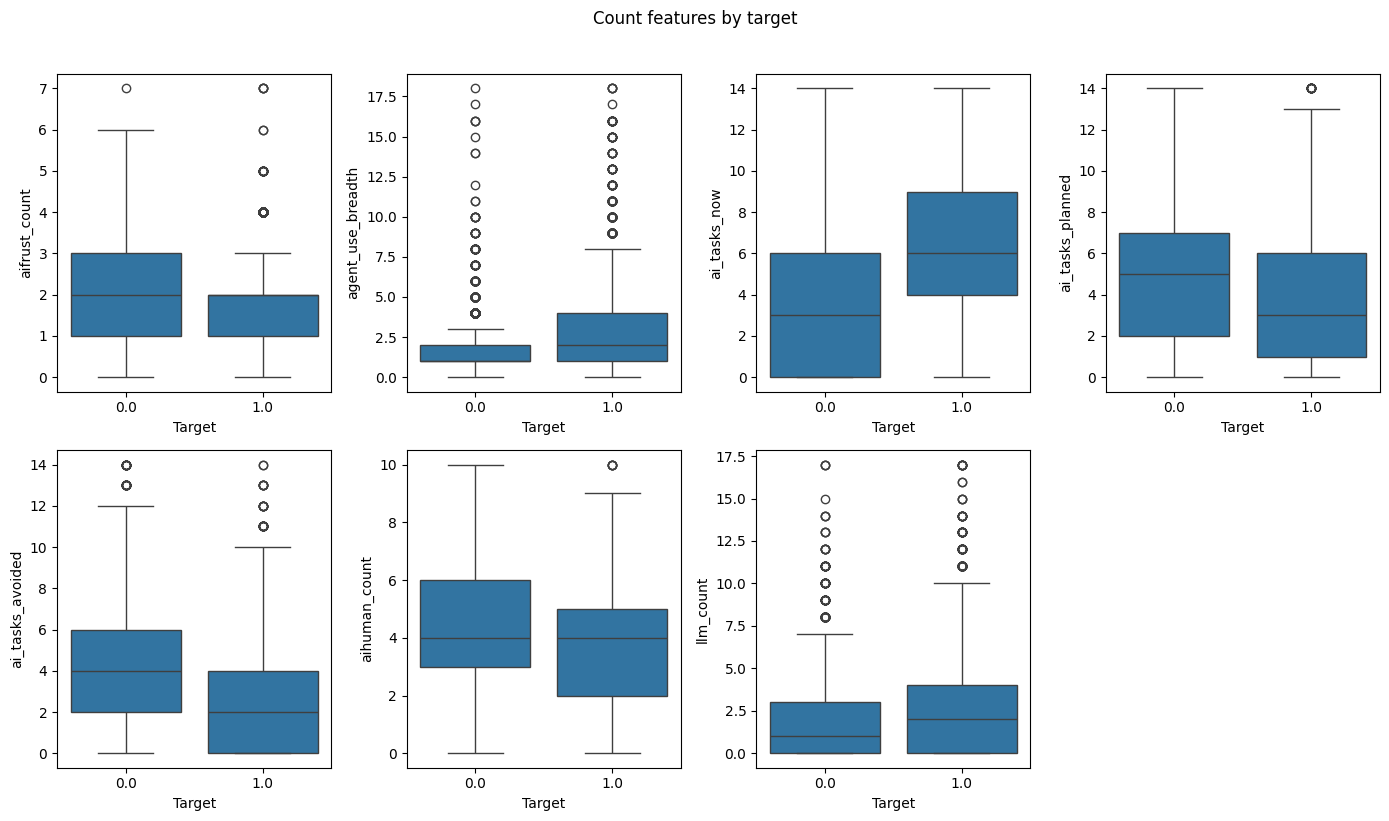

In [12]:
# Plot 3 — Count features by target (box plots, 2×4)
count_cols = ["aifrust_count", "agent_use_breadth", "ai_tasks_now", "ai_tasks_planned", "ai_tasks_avoided", "aihuman_count", "llm_count"]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for i, col in enumerate(count_cols):
    ax = axes.flat[i]
    sns.boxplot(data=df, x="target", y=col, ax=ax)
    ax.set_xlabel("Target")
    ax.set_ylabel(col)
axes.flat[7].axis("off")
plt.suptitle("Count features by target", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** We expect higher agent_use_breadth, ai_tasks_now, ai_tasks_planned, llm_count for agree (1); ai_tasks_avoided and possibly aifrust_count may be higher for disagree (0). Directions help validate feature usefulness.

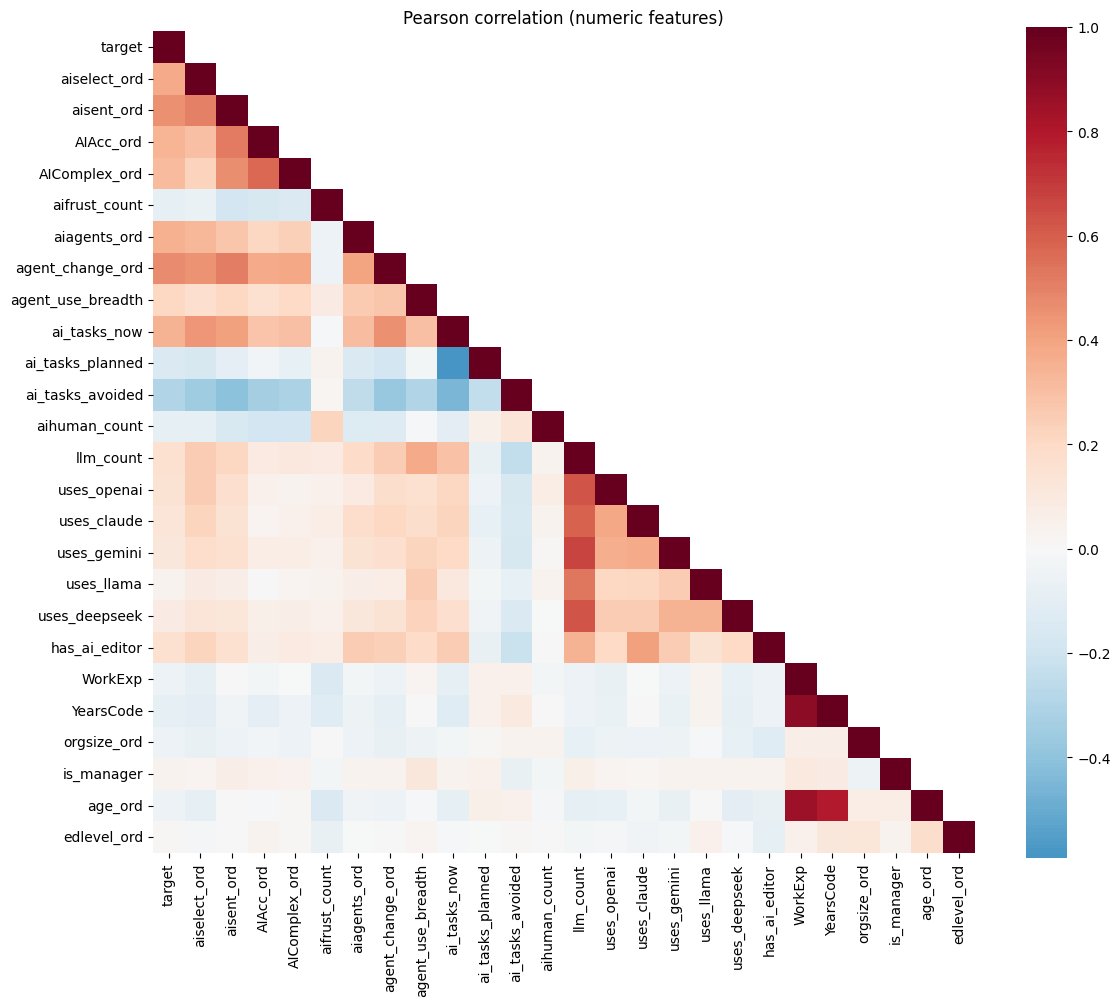

In [13]:
# Plot 4 — Pearson correlation heatmap
num_for_corr = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or c == "target"]
df_num = df[num_for_corr].copy()
df_num["target"] = df_num["target"].astype(float)
corr = df_num.corr(method="pearson")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r", center=0, square=True, ax=ax)
plt.title("Pearson correlation (numeric features)")
plt.tight_layout()
plt.show()

**Observation:** High correlation between some ordinals (e.g. aiselect_ord and aiagents_ord, aisent_ord and AIAcc_ord) indicates multicollinearity risk; consider dropping or combining if needed. High correlation with target is desirable.

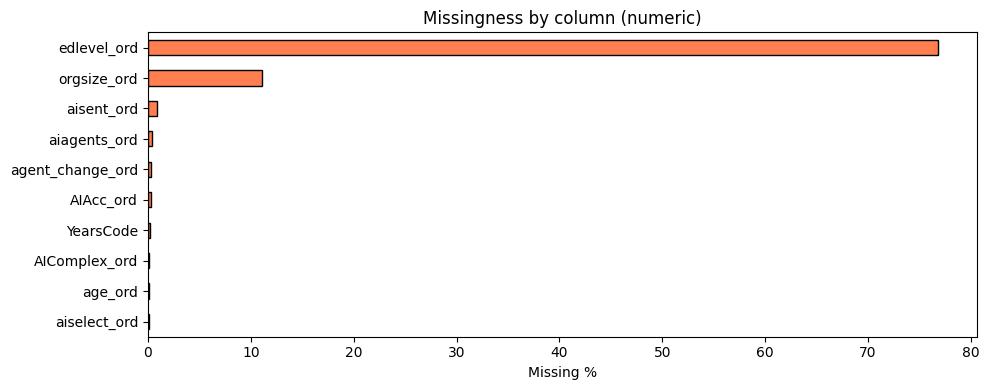

In [14]:
# Plot 5 — Missingness bar chart
num_cols = [c for c in df.columns if c not in ["target", "RemoteWork", "Industry", "DevTypeBucket"] and pd.api.types.is_numeric_dtype(df[c])]
miss_pct = pd.Series({c: df[c].isna().mean() * 100 for c in num_cols}).sort_values(ascending=True)
miss_pct = miss_pct[miss_pct > 0]
if len(miss_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(miss_pct) * 0.35)))
    miss_pct.plot(kind="barh", ax=ax, color="coral", edgecolor="black")
    ax.set_xlabel("Missing %")
    ax.set_title("Missingness by column (numeric)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in numeric columns.")

**Observation:** edlevel_ord dominates missingness (~76–77%); orgsize_ord is next. Remaining columns have low missingness. We exclude edlevel_ord and orgsize_ord from _is_missing indicators by design (see Section 7).

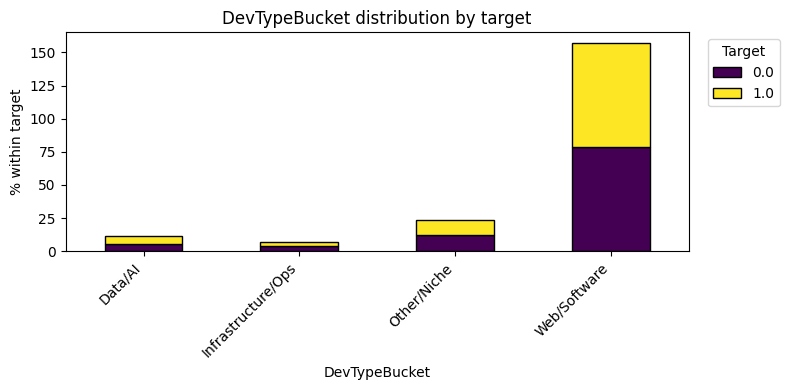

In [15]:
# Plot 6 — Stacked bar: DevTypeBucket distribution by target
ct = pd.crosstab(df["target"], df["DevTypeBucket"], normalize="index") * 100
ct.T.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="viridis", edgecolor="black")
plt.xlabel("DevTypeBucket")
plt.ylabel("% within target")
plt.title("DevTypeBucket distribution by target")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Data/AI and Web/Software roles may show different agree rates; stacked bars show how role mix varies by target and can inform whether DevTypeBucket is predictive.

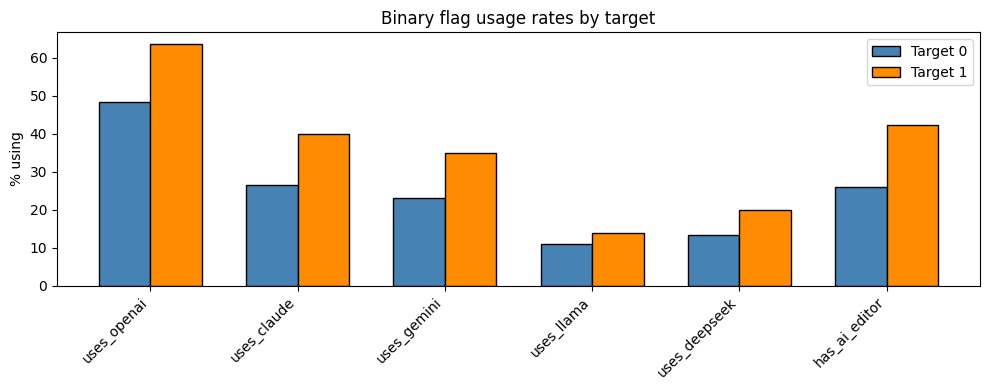

In [16]:
# Plot 7 — Binary flag rates by target (uses_openai, uses_claude, etc.)
flag_cols = ["uses_openai", "uses_claude", "uses_gemini", "uses_llama", "uses_deepseek", "has_ai_editor"]
rates = df.groupby("target")[flag_cols].mean() * 100
x = np.arange(len(flag_cols))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, rates.loc[0], w, label="Target 0", color="steelblue", edgecolor="black")
ax.bar(x + w/2, rates.loc[1], w, label="Target 1", color="darkorange", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(flag_cols, rotation=45, ha="right")
ax.set_ylabel("% using")
ax.set_title("Binary flag usage rates by target")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Agree (target=1) respondents tend to have higher usage rates for each LLM/editor flag; has_ai_editor and uses_openai are strong candidates for predictive power.

## Section 7 — Missingness Audit

Run the audit: null_pct table and flag columns with > 10% missing. We exclude orgsize_ord and edlevel_ord from _is_missing by design.

In [17]:
num_cols_audit = [c for c in df.columns if c != "target" and pd.api.types.is_numeric_dtype(df[c])]
audit = pd.DataFrame({"col": num_cols_audit})
audit["null_count"] = audit["col"].map(lambda c: df[c].isna().sum())
audit["null_pct"] = (audit["null_count"] / len(df) * 100).round(2)
audit = audit.sort_values("null_pct", ascending=False)
print("Column       | null count | null %")
print("-" * 40)
for _, r in audit.iterrows():
    print(f"{r['col']:13} | {r['null_count']:>10} | {r['null_pct']:>6}%")
exceed_10 = audit[audit["null_pct"] > 10]["col"].tolist()
below_10 = audit[audit["null_pct"].between(0.01, 10)]["col"].tolist()
print("\nExceed 10% (would get _is_missing):", exceed_10 if exceed_10 else "none")
print("Below 10% (impute only):", below_10 if below_10 else "none")
print("Excluded from _is_missing by design: orgsize_ord, edlevel_ord")

Column       | null count | null %
----------------------------------------
edlevel_ord   |       7306 |   76.8%
orgsize_ord   |       1059 |  11.13%
aisent_ord    |         88 |   0.93%
aiagents_ord  |         40 |   0.42%
agent_change_ord |         30 |   0.32%
AIAcc_ord     |         26 |   0.27%
YearsCode     |         22 |   0.23%
AIComplex_ord |         14 |   0.15%
age_ord       |          9 |   0.09%
aiselect_ord  |          7 |   0.07%
ai_tasks_now  |          0 |    0.0%
aifrust_count |          0 |    0.0%
agent_use_breadth |          0 |    0.0%
ai_tasks_planned |          0 |    0.0%
ai_tasks_avoided |          0 |    0.0%
aihuman_count |          0 |    0.0%
llm_count     |          0 |    0.0%
uses_llama    |          0 |    0.0%
uses_gemini   |          0 |    0.0%
uses_claude   |          0 |    0.0%
uses_openai   |          0 |    0.0%
WorkExp       |          0 |    0.0%
has_ai_editor |          0 |    0.0%
uses_deepseek |          0 |    0.0%
is_manager    |        

**Design decision:** We do not add _is_missing for orgsize_ord or edlevel_ord. edlevel_ord has ~76–77% missingness (non-random skip of demographics); adding an indicator would dominate the model. orgsize_ord at ~11% is largely freelancers who already have a meaningful value; we treat missing as non-informative and exclude the indicator.

## Section 8 — Preprocessing (Phase 2 requirement 2)

Median-impute numeric columns; add _is_missing only when missingness > 10% and column is not orgsize_ord or edlevel_ord. One-hot encode RemoteWork, Industry, DevTypeBucket (fix "Other:" → "Other", fillna("Unknown") for RemoteWork and Industry). Use drop_first=False.

In [18]:
# Median impute + conditional _is_missing
num_cols = [c for c in df.columns if c not in ["target", "RemoteWork", "Industry", "DevTypeBucket"] and pd.api.types.is_numeric_dtype(df[c])]
for c in num_cols:
    miss_rate = df[c].isna().mean()
    if miss_rate > 0:
        if miss_rate > 0.10 and c not in ["orgsize_ord", "edlevel_ord"]:
            df[f"{c}_is_missing"] = df[c].isna().astype(int)
        df[c] = df[c].fillna(df[c].median())

# OHE: fix "Other:" -> "Other", fillna("Unknown") for RemoteWork and Industry
df["RemoteWork"] = df["RemoteWork"].fillna("Unknown")
df["Industry"] = df["Industry"].fillna("Unknown")
df["Industry"] = df["Industry"].replace("Other:", "Other")
df["DevTypeBucket"] = df["DevTypeBucket"].replace("Other:", "Other").fillna("Other")
ohe = pd.get_dummies(df[["RemoteWork", "Industry", "DevTypeBucket"]], prefix=["RemoteWork", "Industry", "DevType"], drop_first=False)
df = df.drop(columns=["RemoteWork", "Industry", "DevTypeBucket"])
df = pd.concat([df, ohe], axis=1)
print("Final shape:", df.shape)
print("(Expected ~9513 rows × ~45 columns)")

Final shape: (9513, 45)
(Expected ~9513 rows × ~45 columns)


**Justifications:** **Median impute** — robust to outliers (e.g. WorkExp, YearsCode). **_is_missing** — only for columns with >10% missing and not orgsize_ord/edlevel_ord, so the model can use "missing" as signal where it is informative. **OHE** — categoricals (RemoteWork, Industry, DevTypeBucket) have no natural order; OHE preserves all levels. **drop_first=False** — keeps all dummies for interpretability and avoids reference-level dependency; regularization can handle multicollinearity if needed. **fillna("Unknown")** — ensures no NaNs in categoricals before OHE.

## Section 9 — Baseline Models (preview)

Run Logistic Regression and Random Forest with 5-fold CV (roc_auc, class_weight="balanced"). Plot top 15 RF feature importances.

LogisticRegression AUC: 0.847 ± 0.013
RandomForest       AUC: 0.849 ± 0.009


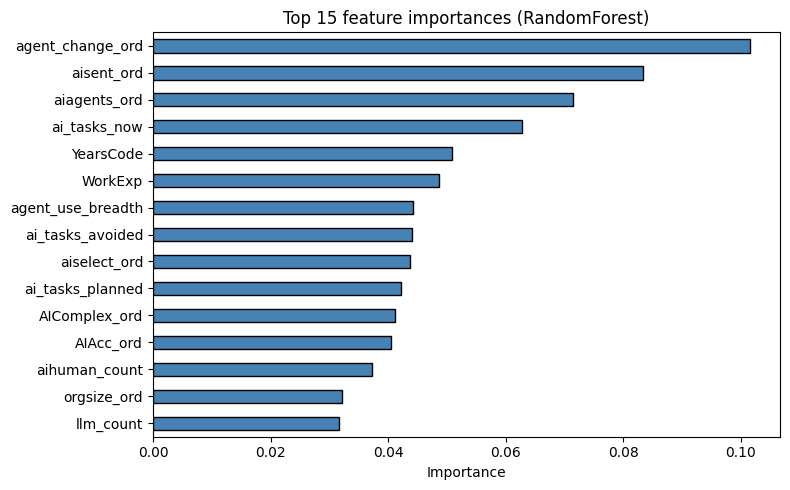

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = df.drop(columns=["target"])
y = df["target"].astype(int)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
lr_auc = cross_val_score(lr, X, y, cv=5, scoring="roc_auc")
rf_auc = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print("LogisticRegression AUC: {:.3f} ± {:.3f}".format(lr_auc.mean(), lr_auc.std()))
print("RandomForest       AUC: {:.3f} ± {:.3f}".format(rf_auc.mean(), rf_auc.std()))
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Top 15 feature importances (RandomForest)")
plt.tight_layout()
plt.show()

**Interpretation:** AUC around 0.84–0.85 indicates strong signal. AI attitude ordinals (aiselect_ord, aisent_ord, agent_change_ord, AIAcc_ord) and usage counts (ai_tasks_now, llm_count, agent_use_breadth) typically dominate importance; demographics (age_ord, edlevel_ord) rank lower. Tree-based models are well-suited for Phase 3.

## Section 10 — Save Preprocessed Data

Save the final model-ready DataFrame to `phase2_preprocessed.csv` for Phase 3.

In [20]:
df.to_csv("phase2_preprocessed.csv", index=False)
print("Saved phase2_preprocessed.csv with shape:", df.shape)

Saved phase2_preprocessed.csv with shape: (9513, 45)
